# Task 1 — Exploratory Data Analysis
## Allocation Algorithm Logs — 2024-01-05

**Goal:** Gain insight into the fulfilment network and the production allocation algorithm.  
Identify quality metrics that reflect how good or bad an allocation is.

### Dataset summary
| File | Description |
|------|-------------|
| `allocation_algorithm_logs_20240105.csv` | 3,810 allocation requests for a single day |
| `courier_costs.csv` | Courier cost table: delivery_type × courier × LMR → cost |
| `courier_post_code_mapping.csv` | Postal code → LMR zone + preferred courier |
| `dc_branch_numbers.csv` | Which branches are Distribution Centres |
| `bash_fcm_facilities.csv` | facility_id → postal_code |

**Key business rule:** All items in an order allocated to the **same facility** ship as **one parcel** (one courier charge).  
Splitting an order across N facilities = N parcels = N courier charges.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data_loader import (
    load_orders, load_items, load_inventory, load_reservations,
    load_courier_costs, load_postcode_mapping, load_dc_branches, load_facilities,
)
from src.cost_engine import CostEngine

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2d3148',
    'axes.labelcolor':  '#dde1f0',
    'xtick.color':      '#7a7f9a',
    'ytick.color':      '#7a7f9a',
    'text.color':       '#dde1f0',
    'grid.color':       '#2d3148',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'figure.titlesize': 14,
    'axes.titlesize':   12,
    'axes.titlepad':    10,
    'font.family':      'DejaVu Sans',
})
PALETTE = ['#6c8ef5', '#4ecdc4', '#f5a623', '#e05d6f', '#a29bfe', '#fd79a8']
sns.set_palette(PALETTE)

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load all DataFrames ─────────────────────────────────────────────────────
orders = load_orders()
items  = load_items()
inv    = load_inventory()
res    = load_reservations()

costs  = load_courier_costs()
pc_map = load_postcode_mapping()
dc_br  = load_dc_branches()
fac    = load_facilities()

engine = CostEngine()

print(f'orders       : {len(orders):,} rows')
print(f'items        : {len(items):,} rows')
print(f'inventory    : {len(inv):,} rows')
print(f'reservations : {len(res):,} rows')


orders       : 3,810 rows
items        : 8,626 rows
inventory    : 104,777 rows
reservations : 9,474 rows


---
## 0. Data Quality Audit & Cleaning

Before any analysis, we fix all known data inconsistencies.  
These findings come from a systematic audit of every field and cross-table join.

| Issue | Severity | Fix applied |
|-------|----------|--------------|
| Province name typos (`'Gauteng '`, `'Kwazulu-Natal'`) | 🟡 | Strip + canonical map |
| `facility_region` = LOCAL for ALL rows (unreliable) | 🔴 | Drop it; use postal code → LMR lookup exclusively |
| Unknown couriers `same_store` & `lfs` not in cost table | 🔴 | Tag separately; assign cost = 0 (same_store) and NaN (lfs) |
| `order_item_id` not globally unique — reused across orders | 🟡 | Always key on `(order_idx, order_item_id)` composite |
| 6 unallocated items (partial stock-outs) | 🟢 | Documented as genuine cancellations |
| 8 destination postal codes missing from LMR mapping | 🟢 | LMR = None for those orders |
| 11 very large orders (>15 items, max 44) | 🟢 | Noted as outliers; greedy allocation for Task 2 |

In [3]:
# ══════════════════════════════════════════════════════════════
# DATA QUALITY FIXES — applied once, propagates to all cells
# ══════════════════════════════════════════════════════════════

# ── FIX 1: Province name normalisation ────────────────────────
PROVINCE_MAP = {
    'Gauteng ':     'Gauteng',
    'Kwazulu-Natal': 'KwaZulu-Natal',
}
orders['destination_province'] = orders['destination_province'].str.strip().replace(PROVINCE_MAP)
inv['facility_province']       = inv['facility_province'].str.strip().replace(PROVINCE_MAP)

print('✓ FIX 1 — Province names normalised')
print(' ', sorted(orders['destination_province'].dropna().unique()))

# ── FIX 2: facility_region is unreliable (all = LOCAL) ────────
# Document this so downstream code does NOT use it for LMR.
# We rely entirely on: facility_id → bash_fcm_facilities → postal_code
#                      → courier_post_code_mapping → LMR
# 100% of inventory facilities resolve correctly via this path.
print('\n✓ FIX 2 — facility_region acknowledged as unreliable (all = LOCAL)')
print('   LMR will be resolved exclusively via postal code lookup.')

# ── FIX 3: Tag special couriers ───────────────────────────────
# same_store: in-store pickup, customer collects → parcel cost = 0
# lfs       : Large Furniture Store DC → separate cost model, not in cost table
KNOWN_COURIERS   = {'courier_a', 'courier_b', 'courier_c'}
ZERO_COST_COURIERS = {'same_store'}   # no parcel shipped
EXTERNAL_COURIERS  = {'lfs'}          # external cost model, out of scope

res['courier_type'] = res['courier'].apply(
    lambda c: 'standard'  if c in KNOWN_COURIERS
         else 'zero_cost' if c in ZERO_COST_COURIERS
         else 'external'
)

print('\n✓ FIX 3 — Courier types tagged:')
print(res['courier_type'].value_counts().to_string())

# ── FIX 4: Composite key for items ────────────────────────────
# order_item_id is NOT globally unique — it repeats across orders.
# Add a composite key for any cross-table join that needs uniqueness.
items['item_key'] = items['order_idx'].astype(str) + '_' + items['order_item_id']
res['item_key']   = res['order_idx'].astype(str)   + '_' + res['order_item_id']

n_dup = items['order_item_id'].duplicated().sum()
print(f'\n✓ FIX 4 — Composite item key added ({n_dup} duplicate order_item_ids now safely keyed)')

# ── FIX 5: Flag unallocated items ─────────────────────────────
allocated_keys = set(res['item_key'])
items['is_allocated'] = items['item_key'].isin(allocated_keys)
print(f'\n✓ FIX 5 — Allocation flag set on items')
print(f'   Allocated: {items["is_allocated"].sum():,}  |  Unallocated: {(~items["is_allocated"]).sum()} (partial stock-outs)')

# ── FIX 6: Flag orders with unknown postal codes ───────────────
from src.data_loader import load_postcode_mapping as _load_pc
_pc = _load_pc()
_pc_set = set(_pc['PostalCode'])
orders['postal_in_mapping'] = orders['destination_postal'].str.zfill(4).isin(_pc_set)
n_missing_postal = (~orders['postal_in_mapping']).sum()
print(f'\n✓ FIX 6 — {n_missing_postal} orders flagged with postal not in LMR mapping')
print(f'   Their LMR zone will be None (0.2% of orders)')

print('\n' + '═'*50)
print('ALL DATA QUALITY FIXES APPLIED')
print('═'*50)

✓ FIX 1 — Province names normalised
  ['Eastern Cape', 'Free State', 'Gauteng', 'KwaZulu-Natal', 'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']

✓ FIX 2 — facility_region acknowledged as unreliable (all = LOCAL)
   LMR will be resolved exclusively via postal code lookup.

✓ FIX 3 — Courier types tagged:
courier_type
standard     9337
zero_cost      85
external       52



✓ FIX 4 — Composite item key added (127 duplicate order_item_ids now safely keyed)

✓ FIX 5 — Allocation flag set on items
   Allocated: 8,620  |  Unallocated: 6 (partial stock-outs)

✓ FIX 6 — 8 orders flagged with postal not in LMR mapping
   Their LMR zone will be None (0.2% of orders)

══════════════════════════════════════════════════
ALL DATA QUALITY FIXES APPLIED
══════════════════════════════════════════════════


---
## 1. Reference Data — Cost Table & Network Coverage

In [4]:
# ── 1a. Cost table ──────────────────────────────────────────────────────────
print('=== Courier Cost Table ===')
costs_disp = costs.copy()
costs_disp['cost_display'] = costs_disp['cost'].apply(lambda c: 'N/A' if c >= 9999 else f'R{c/100:.2f}')
pivot = costs_disp.pivot_table(index=['delivery_type','courier_id'], columns='lmr', values='cost_display', aggfunc='first')
print(pivot.to_string())
print()
print('Note: cost is in cents (South African Rand). N/A = not available (sentinel 10000).')

=== Courier Cost Table ===
lmr                       Local   Main Regional
delivery_type courier_id                       
DoorToDoor    courier_a   R0.46  R0.69    R0.87
              courier_b   R0.55  R0.72    R0.95
              courier_c   R0.20    N/A      N/A
StorePickup   courier_a   R0.22  R0.38    R0.62
              courier_b   R0.62  R0.62    R0.62
              courier_c     N/A    N/A      N/A

Note: cost is in cents (South African Rand). N/A = not available (sentinel 10000).


In [5]:
# ── 1b. LMR zone distribution across postal codes ────────────────────────────
lmr_counts = pc_map['LMR'].value_counts()
print('LMR zone distribution across South African postal codes:')
for zone, cnt in lmr_counts.items():
    print(f'  {zone:10s}: {cnt:5,} postal codes ({cnt/len(pc_map)*100:.1f}%)')

print(f'\nTotal postal codes in mapping: {len(pc_map):,}')
print(f'DC branches in whitelist      : {len(dc_br)}')
print(f'Facilities with postal lookup : {len(fac):,}')

LMR zone distribution across South African postal codes:
  Regional  : 5,953 postal codes (49.0%)
  Main      : 4,988 postal codes (41.1%)
  Local     : 1,202 postal codes (9.9%)

Total postal codes in mapping: 12,144
DC branches in whitelist      : 32
Facilities with postal lookup : 5,957


In [6]:
# ── 1c. Cheapest cost per LMR zone per delivery type ─────────────────────────
available_costs = costs[costs['available']].copy()
cheapest = available_costs.groupby(['delivery_type', 'lmr'])['cost'].min().reset_index()
cheapest['cost_rand'] = cheapest['cost'] / 100
print('Cheapest available courier cost (R) by delivery type and LMR zone:')
print(cheapest.pivot(index='delivery_type', columns='lmr', values='cost_rand').to_string())

Cheapest available courier cost (R) by delivery type and LMR zone:
lmr            Local  Main  Regional
delivery_type                       
DoorToDoor      0.20  0.69      0.87
StorePickup     0.22  0.38      0.62


---
## 2. Order Characteristics

In [7]:
# ── 2a. Items per order ──────────────────────────────────────────────────────
# Note: orders already has n_items from the parser; we compute the rest here.
items_per_order = items.groupby('order_idx').agg(
    n_unique_skus=('sku', 'nunique'),
    n_trading_companies=('trading_company_number', 'nunique'),
    total_quantity=('quantity', 'sum'),
    has_excluded_branches=('has_excluded_branches', 'any'),
    has_alternative_sku=('has_alternative_sku', 'any'),
).reset_index()

print('Items per order distribution (from orders table):')
print(orders['n_items'].describe().round(2).to_string())
print()
print('Value counts:')
print(orders['n_items'].value_counts().sort_index().to_string())

Items per order distribution (from orders table):
count    3810.00
mean        2.26
std         2.32
min         1.00
25%         1.00
50%         1.00
75%         3.00
max        44.00

Value counts:
n_items
1     2000
2      751
3      431
4      229
5      152
6       89
7       48
8       25
9       25
10      12
11      12
12       6
13       4
14       9
15       6
16       2
19       1
20       1
21       1
23       1
24       1
27       1
28       1
30       1
44       1


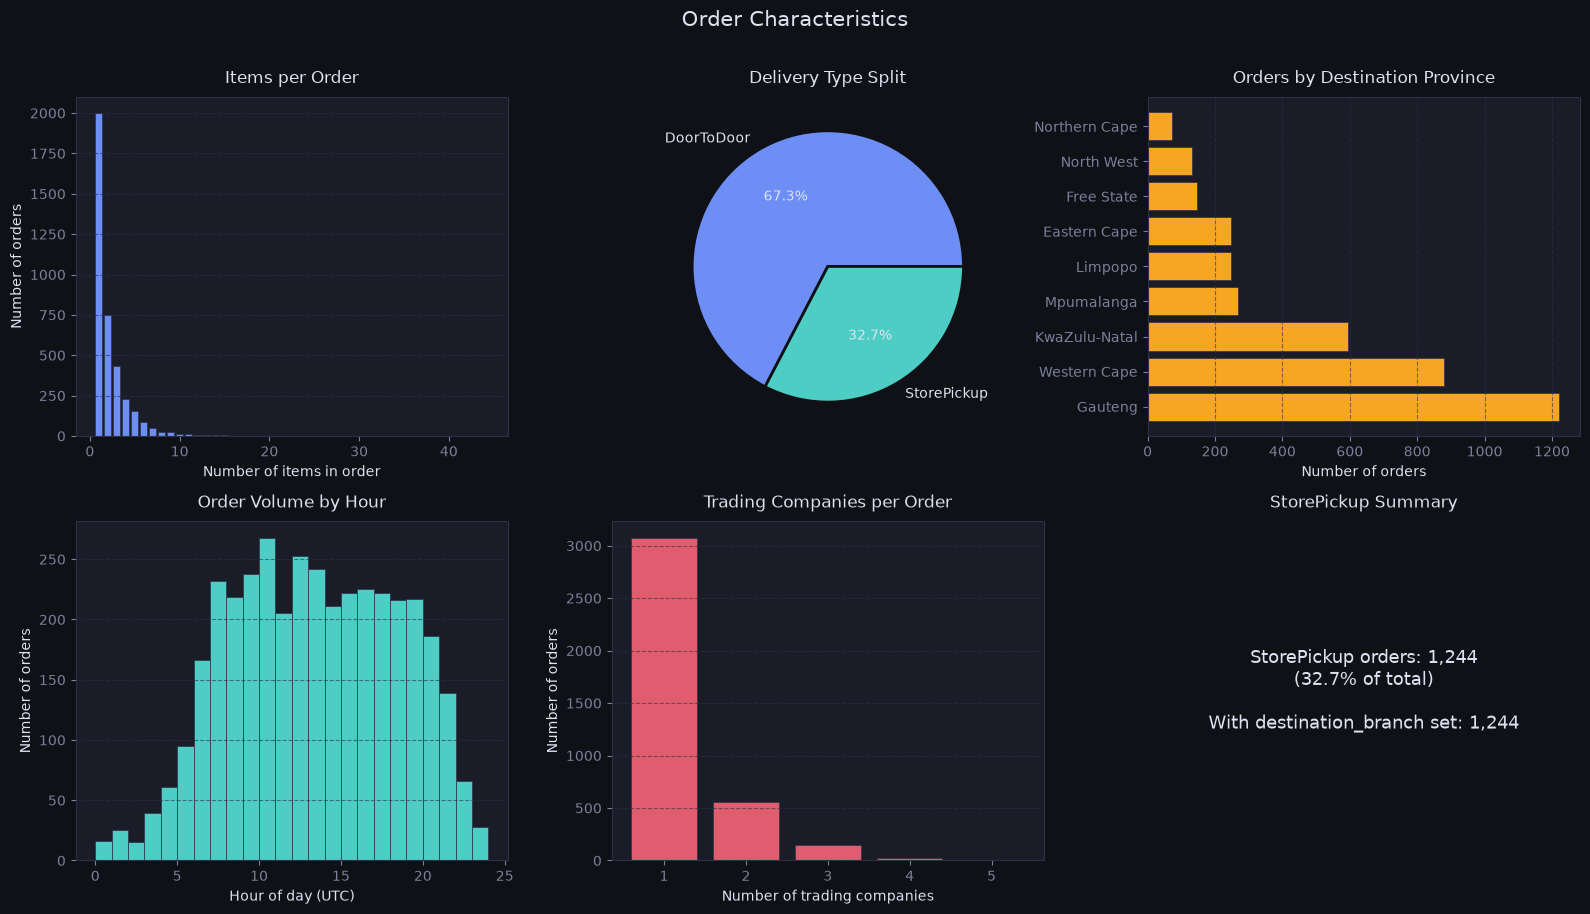

Figure saved.


In [8]:
# ── 2b. Order characteristic plots ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Order Characteristics', fontsize=15, y=1.01)

# n_items distribution
ax = axes[0, 0]
vc = orders['n_items'].value_counts().sort_index()
ax.bar(vc.index, vc.values, color=PALETTE[0], edgecolor='#2d3148', linewidth=0.5)
ax.set_xlabel('Number of items in order')
ax.set_ylabel('Number of orders')
ax.set_title('Items per Order')
ax.grid(axis='y')

# Delivery type
ax = axes[0, 1]
dt_counts = orders['delivery_type'].value_counts()
wedges, texts, autotexts = ax.pie(
    dt_counts.values, labels=dt_counts.index,
    autopct='%1.1f%%', colors=PALETTE[:2],
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2}
)
for t in texts + autotexts:
    t.set_color('#dde1f0')
ax.set_title('Delivery Type Split')

# Destination province
ax = axes[0, 2]
prov = orders['destination_province'].value_counts()
ax.barh(prov.index, prov.values, color=PALETTE[2], edgecolor='#2d3148', linewidth=0.5)
ax.set_xlabel('Number of orders')
ax.set_title('Orders by Destination Province')
ax.grid(axis='x')

# Hour of day
ax = axes[1, 0]
hours = orders['order_created_at'].dt.hour
ax.hist(hours, bins=24, range=(0, 24), color=PALETTE[1], edgecolor='#2d3148', linewidth=0.5)
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Number of orders')
ax.set_title('Order Volume by Hour')
ax.grid(axis='y')

# n_trading_companies per order
ax = axes[1, 1]
tc = items_per_order['n_trading_companies'].value_counts().sort_index()
ax.bar(tc.index.astype(str), tc.values, color=PALETTE[3], edgecolor='#2d3148', linewidth=0.5)
ax.set_xlabel('Number of trading companies')
ax.set_ylabel('Number of orders')
ax.set_title('Trading Companies per Order')
ax.grid(axis='y')

# StorePickup destination branch
ax = axes[1, 2]
sp_orders = orders[orders['delivery_type'] == 'StorePickup']
ax.text(0.5, 0.5,
    f'StorePickup orders: {len(sp_orders):,}\n({len(sp_orders)/len(orders)*100:.1f}% of total)\n\n'
    f'With destination_branch set: {sp_orders["destination_branch"].notna().sum():,}',
    ha='center', va='center', transform=ax.transAxes,
    fontsize=13, color='#dde1f0'
)
ax.set_title('StorePickup Summary')
ax.axis('off')

plt.tight_layout()
plt.savefig('../data/cache/fig_01_order_characteristics.png', dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Figure saved.')

---
## 3. Fulfilment Network Overview

In [9]:
# ── 3a. Unique facilities in the dataset ──────────────────────────────────────
# Get unique facility records from inventory
fac_info = inv.drop_duplicates('facility_id')[[
    'facility_id', 'branch_number', 'facility_type', 'facility_region',
    'facility_province', 'facility_active', 'facility_at_capacity', 'courier_c_active'
]].copy()

# Label DCs using the dc_branch_numbers whitelist
dc_set = set(dc_br['branch_number'].str.zfill(6))
# A facility is a DC if either:
#   (a) its branch_number is in the dc_branch_numbers whitelist, OR
#   (b) its facility_type in the inventory is 'DistributionCentre'
# The whitelist misses 4 DCs (016347, 012993, 330102, 330104) so we use both sources.
fac_info['is_dc'] = (
    fac_info['branch_number'].str.zfill(6).isin(dc_set) |
    (fac_info['facility_type'] == 'DistributionCentre')
)
fac_info['facility_label'] = fac_info['is_dc'].map({True: 'DC', False: 'Store'})

print(f'Unique facilities in inventory: {fac_info["facility_id"].nunique():,}')
print()
print('By facility type:')
print(fac_info['facility_label'].value_counts().to_string())
print()
print('By facility region (LMR):')
print(fac_info['facility_region'].value_counts().to_string())
print()
print('By province:')
print(fac_info['facility_province'].value_counts().to_string())
print()
print(f'courier_c enabled: {fac_info["courier_c_active"].sum()} / {len(fac_info)} facilities')
print(f'At capacity       : {fac_info["facility_at_capacity"].sum()} / {len(fac_info)} facilities')
print(f'Inactive          : {(~fac_info["facility_active"]).sum()} / {len(fac_info)} facilities')

Unique facilities in inventory: 353

By facility type:
facility_label
Store    336
DC        17

By facility region (LMR):
facility_region
LOCAL    353

By province:
facility_province
Gauteng          172
Western Cape     102
KwaZulu-Natal     73
North West         3
Free State         2
Eastern Cape       1

courier_c enabled: 29 / 353 facilities
At capacity       : 0 / 353 facilities
Inactive          : 0 / 353 facilities


In [10]:
# ── 3b. Inventory depth ───────────────────────────────────────────────────────
print('Inventory depth (qty_available across all facility-SKU records):')
print(inv['qty_available'].describe().round(2).to_string())
print()

# Stock per facility type
inv_with_label = inv.merge(fac_info[['facility_id', 'facility_label']], on='facility_id', how='left')
print('Mean QtyAvailable by facility type:')
print(inv_with_label.groupby('facility_label')['qty_available'].agg(['mean', 'median', 'sum']).round(2).to_string())
print()

# Candidates per item per order
candidates_per_item = inv.groupby(['order_idx', 'sku'])['facility_id'].nunique().reset_index()
candidates_per_item.columns = ['order_idx', 'sku', 'n_candidates']
print('Candidate facilities per (order, SKU):')
print(candidates_per_item['n_candidates'].describe().round(2).to_string())

Inventory depth (qty_available across all facility-SKU records):
count    104777.00
mean          9.04
std          19.22
min           1.00
25%           2.00
50%           4.00
75%           8.00
max        1160.00

Mean QtyAvailable by facility type:
                 mean  median     sum
facility_label                       
DC              14.29     6.0   37891
Store            8.90     4.0  909010

Candidate facilities per (order, SKU):
count    8588.00
mean       12.20
std        13.11
min         1.00
25%         2.00
50%         7.00
75%        17.00
max        60.00


Full-coverage facility count per order:
count    3810.00
mean       18.94
std        19.92
min         0.00
25%         3.00
50%        12.00
75%        29.00
max       126.00

Orders with 0 full-coverage facilities: 2 (0.1%)
Orders with >=1 full-coverage facility: 3808 (99.9%)


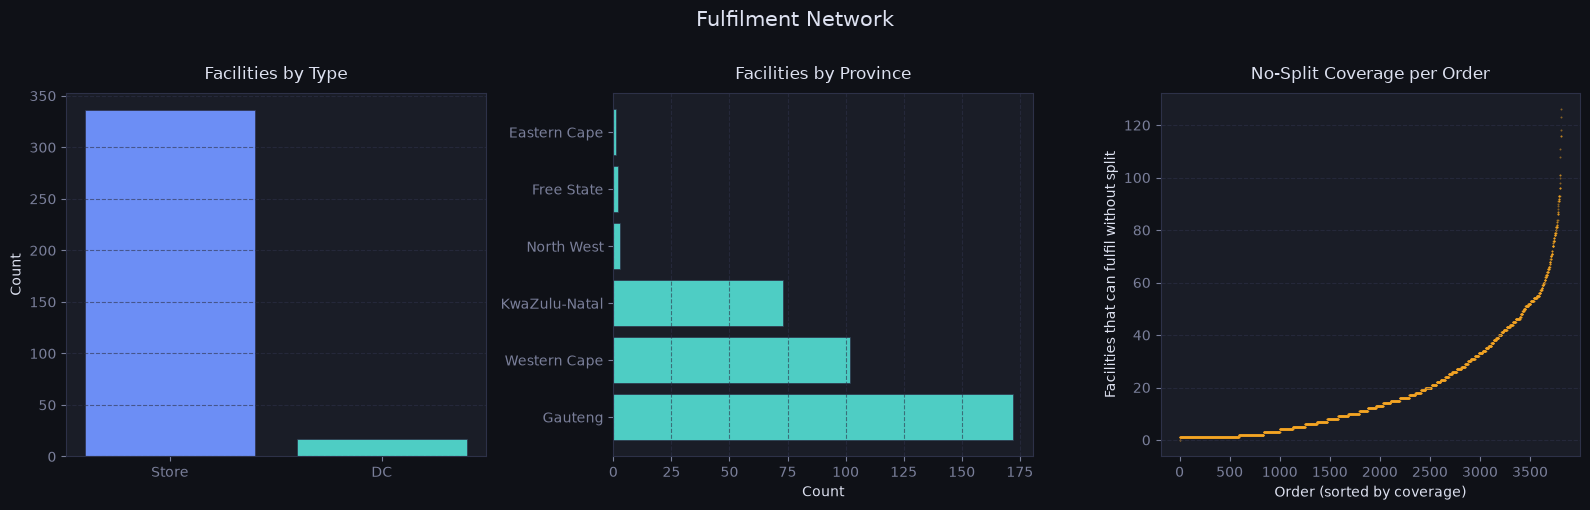

In [11]:
# ── 3c. Network visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fulfilment Network', fontsize=15, y=1.01)

# Facility type
ax = axes[0]
fc_type = fac_info['facility_label'].value_counts()
ax.bar(fc_type.index, fc_type.values, color=PALETTE[:len(fc_type)], edgecolor='#2d3148', linewidth=0.5)
ax.set_title('Facilities by Type')
ax.set_ylabel('Count')
ax.grid(axis='y')

# Province distribution
ax = axes[1]
prov_fc = fac_info['facility_province'].value_counts()
ax.barh(prov_fc.index, prov_fc.values, color=PALETTE[1], edgecolor='#2d3148', linewidth=0.5)
ax.set_title('Facilities by Province')
ax.set_xlabel('Count')
ax.grid(axis='x')

# Full-coverage facilities per order:
# A facility 'fully covers' an order if qty_available >= requested quantity for EVERY item.
# This counts how many such no-split options exist per order.
ax = axes[2]
merged_cov = inv.merge(
    items[['order_idx', 'sku', 'quantity']],
    on=['order_idx', 'sku'], how='inner'
)
merged_cov['can_cover'] = merged_cov['qty_available'] >= merged_cov['quantity']
per_of = merged_cov.groupby(['order_idx', 'facility_id']).agg(
    covered=('can_cover', 'sum'), total=('can_cover', 'count')
).reset_index()
per_of['full_cover'] = per_of['covered'] == per_of['total']
n_full = per_of.groupby('order_idx')['full_cover'].sum()

n_full_sorted = n_full.sort_values().reset_index(drop=True)
ax.scatter(n_full_sorted.index, n_full_sorted.values,
           s=2, color=PALETTE[2], alpha=0.5, linewidths=0)
ax.set_xlabel('Order (sorted by coverage)')
ax.set_ylabel('Facilities that can fulfil without split')
ax.set_title('No-Split Coverage per Order')
ax.grid(axis='y')

print('Full-coverage facility count per order:')
print(n_full.describe().round(2).to_string())
print(f"\nOrders with 0 full-coverage facilities: {(n_full == 0).sum()} ({(n_full == 0).mean()*100:.1f}%)")
print(f"Orders with >=1 full-coverage facility: {(n_full >= 1).sum()} ({(n_full >= 1).mean()*100:.1f}%)")

plt.tight_layout()
plt.savefig('../data/cache/fig_02_network.png', dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

---
## 4. Allocation Quality Metrics

We derive all quality metrics from the **production plan** (the algorithm's actual output).  
These are the KPIs we will use to benchmark our own allocation model (Task 2).

In [12]:
# ── 4a. Build order-level allocation metrics ──────────────────────────────────

# 1) Count distinct facilities (parcels) per order from reservations
parcels = res.groupby('order_idx').agg(
    n_parcels=('branch_number', 'nunique'),
    n_reservations=('reservation_id', 'count'),
    couriers_used=('courier', lambda x: list(x.unique())),
    n_couriers=('courier', 'nunique'),
    fc_codes=('fc_code', lambda x: list(x.unique())),
).reset_index()

# 2) Cancellations: orders with any cancellation in the plan
n_cancellations = res.groupby('order_idx')['n_cancellations'].first().reset_index()

# 3) Merge everything onto orders
# orders already has n_items; merge only the additional columns from items_per_order
metrics = orders.merge(items_per_order[['order_idx','n_unique_skus','n_trading_companies',
                                        'total_quantity','has_excluded_branches','has_alternative_sku']],
                       on='order_idx', how='left')
metrics = metrics.merge(parcels, on='order_idx', how='left')
metrics = metrics.merge(n_cancellations, on='order_idx', how='left')

# Orders that appear in reservations but had nothing reserved get n_parcels = 0
metrics['n_parcels'] = metrics['n_parcels'].fillna(0).astype(int)
metrics['n_cancellations'] = metrics['n_cancellations'].fillna(0).astype(int)
metrics['is_split'] = metrics['n_parcels'] > 1
metrics['is_cancelled'] = metrics['n_cancellations'] > 0  # at least one item cancelled
metrics['fully_cancelled'] = metrics['n_parcels'] == 0

# 4) LMR zone of destination
metrics['dest_lmr'] = metrics['destination_postal'].apply(
    lambda p: engine.lmr_zone(str(p).zfill(4) if pd.notna(p) else None)
)

print(f'Total orders      : {len(metrics):,}')
print(f'Split orders      : {metrics["is_split"].sum():,} ({metrics["is_split"].mean()*100:.1f}%)')
print(f'Any cancellation  : {metrics["is_cancelled"].sum():,} ({metrics["is_cancelled"].mean()*100:.1f}%)')
print(f'Fully cancelled   : {metrics["fully_cancelled"].sum():,} ({metrics["fully_cancelled"].mean()*100:.1f}%)')
print()
print('n_parcels distribution:')
print(metrics['n_parcels'].value_counts().sort_index().to_string())

Total orders      : 3,810
Split orders      : 1,287 (33.8%)
Any cancellation  : 6 (0.2%)
Fully cancelled   : 0 (0.0%)

n_parcels distribution:
n_parcels
1     2523
2      744
3      297
4      131
5       56
6       25
7       12
8        7
9        6
10       4
11       3
12       2


In [13]:
# ── 4b. Compute total cost per order using the cost engine ────────────────────

# For each reservation, look up the facility's LMR zone and cheapest courier cost
res_with_postal = res.merge(
    fac[['facility_id', 'postal_code']].rename(columns={'postal_code': 'facility_postal'}),
    left_on='branch_number',  # we can't directly map branch → facility_id easily
    right_on='facility_id',
    how='left'
)

# Alternative: use inventory to map branch_number → facility info directly
branch_to_inv = inv[['branch_number','facility_id','facility_region','courier_c_active']].drop_duplicates('branch_number')
res_enriched = res.merge(branch_to_inv, on='branch_number', how='left')

# Get facility postal from facilities table via facility_id
res_enriched = res_enriched.merge(
    fac[['facility_id','postal_code']].rename(columns={'postal_code':'fac_postal'}),
    on='facility_id', how='left'
)

# Resolve LMR zone: postal lookup first, fall back to FacilityRegion
def resolve_lmr(row):
    lmr = engine.lmr_zone(row.get('fac_postal'))
    if lmr:
        return lmr
    region_map = {'LOCAL': 'Local', 'MAIN': 'Main', 'REGIONAL': 'Regional'}
    return region_map.get(str(row.get('facility_region', '')), None)

res_enriched['lmr_zone'] = res_enriched.apply(resolve_lmr, axis=1)

# Get delivery_type from orders
res_enriched = res_enriched.merge(orders[['order_idx','delivery_type']], on='order_idx', how='left')

# Compute cost per reservation line
def line_cost(row):
    if pd.isna(row['lmr_zone']) or pd.isna(row['delivery_type']):
        return np.nan
    cost = engine.courier_cost(row['delivery_type'], row['courier'], row['lmr_zone'])
    return cost

res_enriched['parcel_cost'] = res_enriched.apply(line_cost, axis=1)

# Cost is per parcel (per unique branch), not per item line.
# Sum cost once per (order_idx, branch_number) then aggregate to order
parcel_costs = (
    res_enriched.drop_duplicates(['order_idx', 'branch_number'])
    .groupby('order_idx')['parcel_cost']
    .sum()
    .reset_index()
    .rename(columns={'parcel_cost': 'total_cost'})
)

metrics = metrics.merge(parcel_costs, on='order_idx', how='left')
metrics['cost_rand'] = metrics['total_cost'] / 100
metrics['cost_per_item'] = metrics['total_cost'] / metrics['n_items'].replace({0: np.nan})

print('Total cost per order (Rand):')
print(metrics['cost_rand'].describe().round(2).to_string())
print()
print(f'Orders where cost could be computed: {metrics["total_cost"].notna().sum():,}')
print(f'Orders with unknown cost (LMR not resolved): {metrics["total_cost"].isna().sum():,}')

Total cost per order (Rand):
count    3810.00
mean        6.62
std        27.08
min         0.22
25%         0.46
50%         0.69
75%         1.15
max       302.39

Orders where cost could be computed: 3,810
Orders with unknown cost (LMR not resolved): 0


In [14]:
# ── 4c. Courier usage ─────────────────────────────────────────────────────────
# Expand the couriers_used list to get per-order courier analysis
courier_usage = res.groupby(['order_idx','courier']).size().reset_index(name='n_items_with_courier')

print('Courier usage across all reservations:')
courier_total = res['courier'].value_counts()
for courier, cnt in courier_total.items():
    print(f'  {courier}: {cnt:,} reservation lines ({cnt/len(res)*100:.1f}%)')

print()
print('Courier usage by delivery type:')
print(res.merge(orders[['order_idx','delivery_type']], on='order_idx')
        .groupby(['delivery_type','courier'])
        .size().reset_index(name='count')
        .pivot(index='delivery_type', columns='courier', values='count')
        .fillna(0).astype(int).to_string())

print()
print('Courier usage by LMR zone:')
print(res_enriched.groupby(['lmr_zone','courier']).size().reset_index(name='count')
        .pivot(index='lmr_zone', columns='courier', values='count')
        .fillna(0).astype(int).to_string())

Courier usage across all reservations:
  courier_a: 6,939 reservation lines (73.2%)
  courier_b: 2,164 reservation lines (22.8%)
  courier_c: 234 reservation lines (2.5%)
  same_store: 85 reservation lines (0.9%)
  lfs: 52 reservation lines (0.5%)

Courier usage by delivery type:
courier        courier_a  courier_b  courier_c  lfs  same_store
delivery_type                                                  
DoorToDoor          4957       1624        234   42           0
StorePickup         1982        540          0   10          85

Courier usage by LMR zone:
courier   courier_a  courier_b  courier_c  lfs  same_store
lmr_zone                                                  
Local          3170       2164          0   44          45
Main           3610          0        234    8          38
Regional        159          0          0    0           2


In [15]:
# ── 4d. Facility type usage in allocations ────────────────────────────────────
res_with_type = res.merge(fac_info[['branch_number','facility_label','facility_province']],
                          on='branch_number', how='left')

print('Reservations by facility type:')
ftype = res_with_type['facility_label'].value_counts()
for ft, cnt in ftype.items():
    print(f'  {ft or "Unknown":10s}: {cnt:,} ({cnt/len(res)*100:.1f}%)')

print()
print('Source province of allocations:')
print(res_with_type['facility_province'].value_counts().head(10).to_string())

Reservations by facility type:
  Store     : 7,137 (75.3%)
  DC        : 2,337 (24.7%)

Source province of allocations:
facility_province
Gauteng          5527
Western Cape     2180
KwaZulu-Natal    1599
North West        128
Free State         31
Eastern Cape        9


In [16]:
# ── 4e. Same-province rate ───────────────────────────────────────────────────
# Check if source and destination province match for each reservation
res_province = res_with_type.merge(
    orders[['order_idx','destination_province']], on='order_idx', how='left'
)
res_province['same_province'] = (
    res_province['facility_province'] == res_province['destination_province']
)

# Per-order: all items from same province as destination?
order_same_province = res_province.groupby('order_idx')['same_province'].all().reset_index()
rate = order_same_province['same_province'].mean()
print(f'Orders where ALL items came from same province as destination: {rate*100:.1f}%')

any_same = res_province.groupby('order_idx')['same_province'].any().mean()
print(f'Orders where AT LEAST ONE item came from same province as destination: {any_same*100:.1f}%')

Orders where ALL items came from same province as destination: 38.0%
Orders where AT LEAST ONE item came from same province as destination: 48.2%


---
## 5. Core Allocation Quality Plots

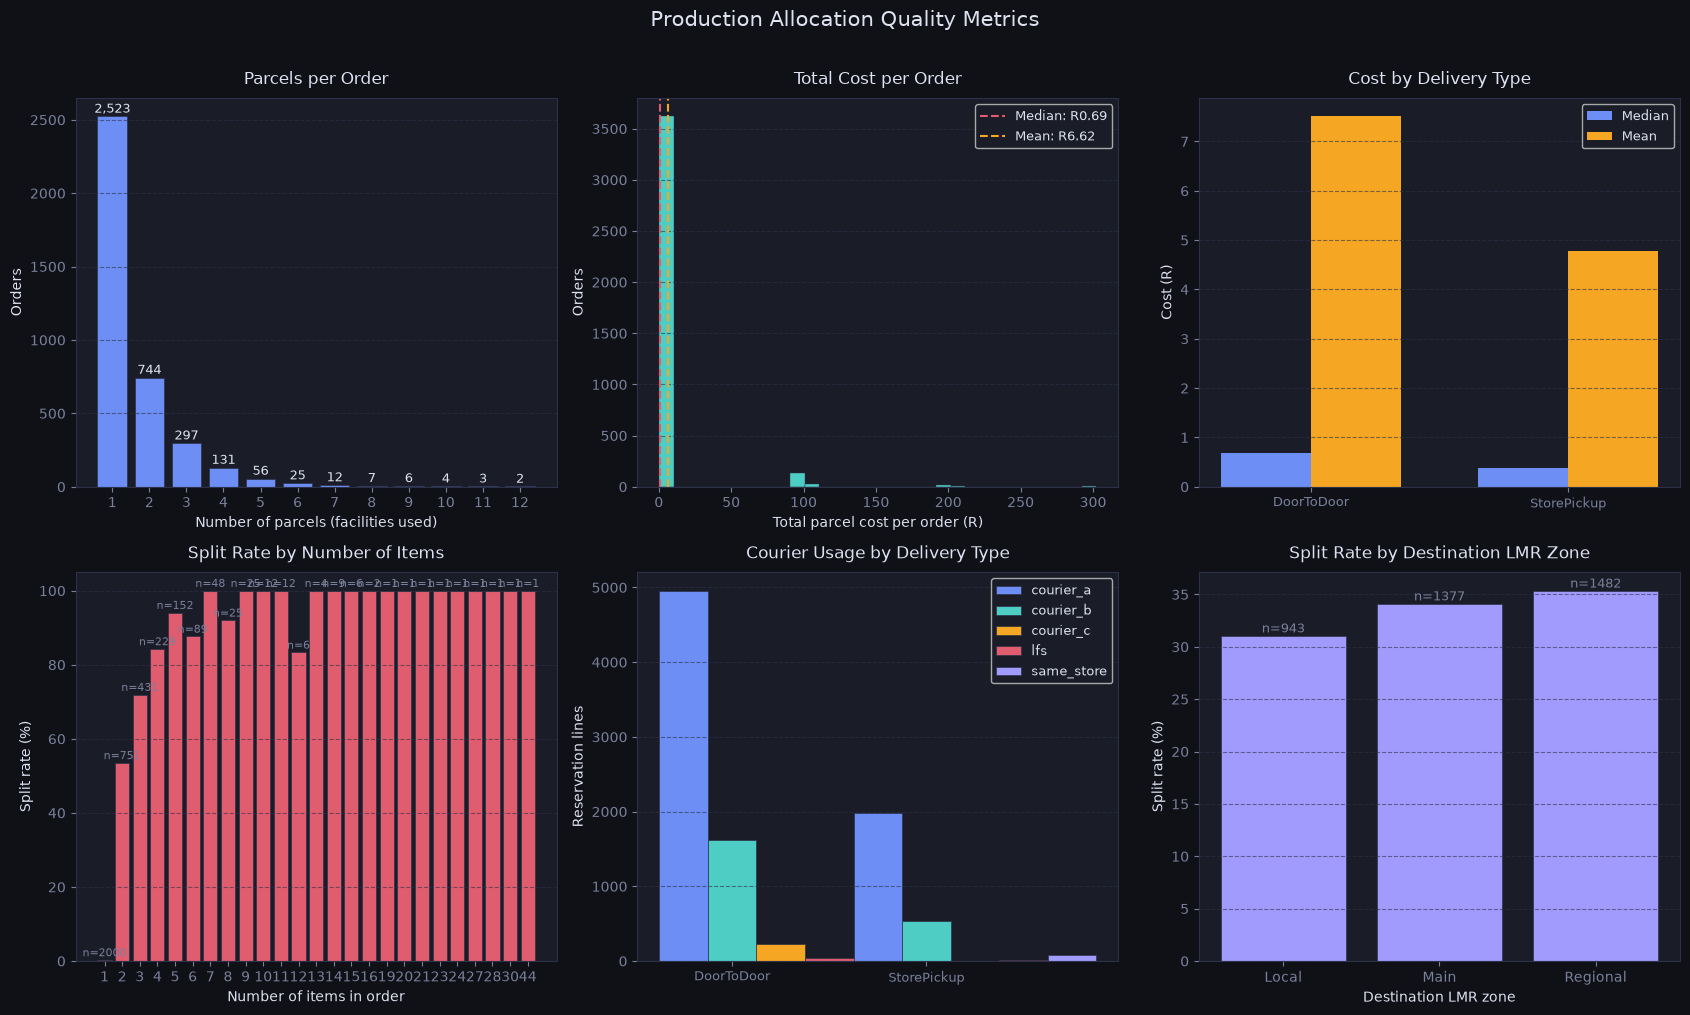

In [17]:
# ── 5a. Main quality metrics dashboard ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Production Allocation Quality Metrics', fontsize=15, y=1.01)

# n_parcels distribution
ax = axes[0, 0]
vc = metrics['n_parcels'].value_counts().sort_index()
bars = ax.bar(vc.index.astype(str), vc.values, color=PALETTE[0], edgecolor='#2d3148', linewidth=0.5)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{v:,}', ha='center', va='bottom', fontsize=9, color='#dde1f0')
ax.set_xlabel('Number of parcels (facilities used)')
ax.set_ylabel('Orders')
ax.set_title('Parcels per Order')
ax.grid(axis='y')

# Cost distribution (Rand)
ax = axes[0, 1]
cost_valid = metrics['cost_rand'].dropna()
ax.hist(cost_valid, bins=30, color=PALETTE[1], edgecolor='#2d3148', linewidth=0.3)
ax.axvline(cost_valid.median(), color=PALETTE[3], linestyle='--', linewidth=1.5, label=f'Median: R{cost_valid.median():.2f}')
ax.axvline(cost_valid.mean(), color=PALETTE[2], linestyle='--', linewidth=1.5, label=f'Mean: R{cost_valid.mean():.2f}')
ax.set_xlabel('Total parcel cost per order (R)')
ax.set_ylabel('Orders')
ax.set_title('Total Cost per Order')
ax.legend(fontsize=9)
ax.grid(axis='y')

# Cost by delivery type
ax = axes[0, 2]
dt_cost = metrics.groupby('delivery_type')['cost_rand'].agg(['median','mean']).reset_index()
x = range(len(dt_cost))
width = 0.35
ax.bar([i - width/2 for i in x], dt_cost['median'], width, label='Median', color=PALETTE[0])
ax.bar([i + width/2 for i in x], dt_cost['mean'],   width, label='Mean',   color=PALETTE[2])
ax.set_xticks(list(x))
ax.set_xticklabels(dt_cost['delivery_type'], fontsize=9)
ax.set_ylabel('Cost (R)')
ax.set_title('Cost by Delivery Type')
ax.legend(fontsize=9)
ax.grid(axis='y')

# Split rate by n_items
ax = axes[1, 0]
split_by_items = metrics.groupby('n_items')['is_split'].mean().reset_index()
split_by_items_cnt = metrics.groupby('n_items').size().reset_index(name='n_orders')
ax.bar(split_by_items['n_items'].astype(str), split_by_items['is_split'] * 100,
       color=PALETTE[3], edgecolor='#2d3148', linewidth=0.5)
ax.set_xlabel('Number of items in order')
ax.set_ylabel('Split rate (%)')
ax.set_title('Split Rate by Number of Items')
ax.grid(axis='y')
# Add order counts on bars
for _, row in split_by_items_cnt.iterrows():
    sr_row = split_by_items[split_by_items['n_items'] == row['n_items']]
    if len(sr_row):
        y = sr_row.iloc[0]['is_split'] * 100
        ax.text(str(row['n_items']), y + 1, f'n={row["n_orders"]}',
                ha='center', fontsize=8, color='#7a7f9a')

# Courier distribution
ax = axes[1, 1]
c_by_dt = res.merge(orders[['order_idx','delivery_type']], on='order_idx')
c_by_dt = c_by_dt.groupby(['delivery_type','courier']).size().reset_index(name='cnt')
couriers = sorted(res['courier'].unique())
dt_vals = c_by_dt['delivery_type'].unique()
xpos = np.arange(len(dt_vals))
bar_w = 0.25
for i, courier in enumerate(couriers):
    vals = [c_by_dt[(c_by_dt['delivery_type']==dt) & (c_by_dt['courier']==courier)]['cnt'].sum() for dt in dt_vals]
    ax.bar(xpos + i * bar_w, vals, bar_w, label=courier, color=PALETTE[i], edgecolor='#2d3148', linewidth=0.5)
ax.set_xticks(xpos + bar_w)
ax.set_xticklabels(dt_vals, fontsize=9)
ax.set_ylabel('Reservation lines')
ax.set_title('Courier Usage by Delivery Type')
ax.legend(fontsize=9)
ax.grid(axis='y')

# Split rate by destination LMR zone
ax = axes[1, 2]
lmr_split = metrics.dropna(subset=['dest_lmr']).groupby('dest_lmr').agg(
    split_rate=('is_split', 'mean'),
    n_orders=('order_idx', 'count')
).reset_index()
bars = ax.bar(lmr_split['dest_lmr'], lmr_split['split_rate'] * 100,
              color=PALETTE[4], edgecolor='#2d3148', linewidth=0.5)
for bar, row in zip(bars, lmr_split.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'n={row.n_orders}', ha='center', fontsize=9, color='#7a7f9a')
ax.set_xlabel('Destination LMR zone')
ax.set_ylabel('Split rate (%)')
ax.set_title('Split Rate by Destination LMR Zone')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('../data/cache/fig_03_quality_metrics.png', dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

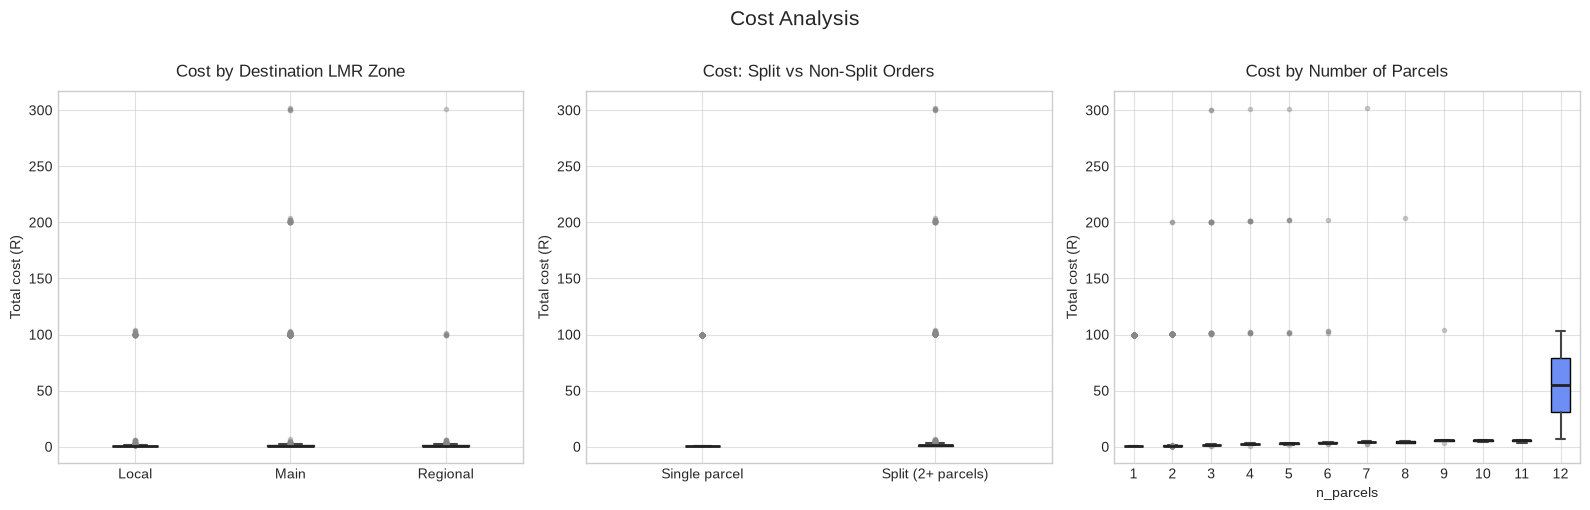

In [18]:
# ── 5b. Cost by LMR zone and split status ────────────────────────────────────
# Use a light style so box plots are clearly visible
with plt.style.context('seaborn-v0_8-whitegrid'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Cost Analysis', fontsize=15, y=1.01)

    BP_PROPS = dict(
        patch_artist=True,
        medianprops={'color': '#222', 'linewidth': 2},
        whiskerprops={'color': '#444', 'linewidth': 1.5},
        capprops={'color': '#444', 'linewidth': 1.5},
        flierprops={'marker': 'o', 'markerfacecolor': '#888',
                    'markeredgecolor': '#888', 'markersize': 3, 'alpha': 0.4},
    )

    # Cost by LMR zone
    ax = axes[0]
    cost_lmr = metrics.dropna(subset=['dest_lmr','cost_rand']).groupby('dest_lmr')['cost_rand']
    lmr_order = ['Local', 'Main', 'Regional']
    data_for_box = [cost_lmr.get_group(z).values for z in lmr_order if z in cost_lmr.groups]
    labels_for_box = [z for z in lmr_order if z in cost_lmr.groups]
    bp = ax.boxplot(data_for_box, tick_labels=labels_for_box, **BP_PROPS)
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title('Cost by Destination LMR Zone')
    ax.set_ylabel('Total cost (R)')

    # Cost: split vs not split
    ax = axes[1]
    cost_split = metrics[metrics['is_split'] & metrics['cost_rand'].notna()]['cost_rand']
    cost_nosplit = metrics[~metrics['is_split'] & metrics['cost_rand'].notna()]['cost_rand']
    bp2 = ax.boxplot([cost_nosplit.values, cost_split.values],
                     tick_labels=['Single parcel', 'Split (2+ parcels)'],
                     **BP_PROPS)
    bp2['boxes'][0].set_facecolor(PALETTE[1]); bp2['boxes'][0].set_alpha(0.75)
    bp2['boxes'][1].set_facecolor(PALETTE[3]); bp2['boxes'][1].set_alpha(0.75)
    ax.set_title('Cost: Split vs Non-Split Orders')
    ax.set_ylabel('Total cost (R)')

    # Cost by n_parcels
    ax = axes[2]
    cost_by_np = metrics[metrics['cost_rand'].notna() & (metrics['n_parcels'] > 0)]
    groups = sorted(cost_by_np['n_parcels'].unique())
    data_np = [cost_by_np[cost_by_np['n_parcels'] == g]['cost_rand'].values for g in groups]
    bp3 = ax.boxplot(data_np, tick_labels=[str(g) for g in groups], **BP_PROPS)
    for patch, color in zip(bp3['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_title('Cost by Number of Parcels')
    ax.set_xlabel('n_parcels')
    ax.set_ylabel('Total cost (R)')

    plt.tight_layout()
    plt.savefig('../data/cache/fig_04_cost_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## 6. Hypothesis Testing

We test the five hypotheses from our plan against the actual data.

In [19]:
# ── H1: Algorithm prefers Local-zone facilities ──────────────────────────────
print('=== HYPOTHESIS 1: Algorithm prefers Local-zone facilities ===')
res_with_lmr = res_enriched.copy()
lmr_dist = res_with_lmr['lmr_zone'].value_counts(dropna=False)
print('LMR zone distribution of CHOSEN facilities:')
for zone, cnt in lmr_dist.items():
    print(f'  {str(zone):12s}: {cnt:5,} ({cnt/len(res_with_lmr)*100:.1f}%)')

# Compare with available inventory LMR distribution
inv_lmr = inv['facility_region'].value_counts(dropna=False)
print()
print('LMR region distribution of ALL AVAILABLE facilities in inventory:')
for zone, cnt in inv_lmr.items():
    print(f'  {str(zone):12s}: {cnt:5,} ({cnt/len(inv)*100:.1f}%)')
print()
print('→ If algorithm prefers Local, we expect Local to be over-represented in chosen vs available.')

=== HYPOTHESIS 1: Algorithm prefers Local-zone facilities ===
LMR zone distribution of CHOSEN facilities:
  Local       : 5,423 (57.2%)
  Main        : 3,890 (41.1%)
  Regional    :   161 (1.7%)

LMR region distribution of ALL AVAILABLE facilities in inventory:
  LOCAL       : 104,777 (100.0%)

→ If algorithm prefers Local, we expect Local to be over-represented in chosen vs available.


In [20]:
# ── H2: DCs used as last resort ───────────────────────────────────────────────
print('=== HYPOTHESIS 2: DCs are used as a last resort over Stores ===')

# What % of reservations use a DC?
res_dc = res.merge(fac_info[['branch_number','facility_label']], on='branch_number', how='left')
dc_usage = res_dc['facility_label'].value_counts(dropna=False)
print('Reservations by facility type:')
for ft, cnt in dc_usage.items():
    print(f'  {str(ft):12s}: {cnt:5,} ({cnt/len(res)*100:.1f}%)')

# Compare: DC usage when item has local store alternative
# Find orders allocated to DC where there WAS a store alternative in inventory
dc_reservations = res_dc[res_dc['facility_label'] == 'DC'][['order_idx','order_item_id','sku']]
# For each DC reservation, check if the inventory had any Store with stock for that (order, sku)
store_inv = inv_with_label[inv_with_label['facility_label'] == 'Store'][['order_idx','sku']].drop_duplicates()
dc_with_store_option = dc_reservations.merge(store_inv, on=['order_idx','sku'], how='left', indicator=True)
had_store = (dc_with_store_option['_merge'] == 'both').sum()
total_dc = len(dc_reservations)
print(f'\nDC reservations where a Store alternative existed: {had_store:,} / {total_dc:,} ({had_store/max(total_dc,1)*100:.1f}%)')
print('→ High % means algorithm chose DC even when store stock was available (not purely last-resort).')

=== HYPOTHESIS 2: DCs are used as a last resort over Stores ===
Reservations by facility type:
  Store       : 7,137 (75.3%)
  DC          : 2,337 (24.7%)

DC reservations where a Store alternative existed: 1,670 / 2,337 (71.5%)
→ High % means algorithm chose DC even when store stock was available (not purely last-resort).


In [21]:
# ── H3: More items → more splits ─────────────────────────────────────────────
print('=== HYPOTHESIS 3: Orders with more items are more likely to be split ===')
split_rate_by_items = metrics.groupby('n_items').agg(
    split_rate=('is_split', 'mean'),
    n_orders=('order_idx', 'count'),
    mean_parcels=('n_parcels', 'mean'),
).reset_index()
print(split_rate_by_items.to_string(index=False))

from scipy.stats import spearmanr
valid = metrics[metrics['n_parcels'] > 0]
rho, p = spearmanr(valid['n_items'], valid['n_parcels'])
print(f'\nSpearman correlation (n_items vs n_parcels): ρ = {rho:.3f}, p = {p:.4f}')
print(f'→ {"Strong support" if abs(rho) > 0.3 else "Weak support"} for H3.')

=== HYPOTHESIS 3: Orders with more items are more likely to be split ===
 n_items  split_rate  n_orders  mean_parcels
       1    0.003000      2000      1.003000
       2    0.535286       751      1.537949
       3    0.719258       431      2.004640
       4    0.842795       229      2.528384
       5    0.940789       152      3.026316
       6    0.876404        89      3.101124
       7    1.000000        48      4.354167
       8    0.920000        25      4.120000
       9    1.000000        25      4.440000
      10    1.000000        12      4.833333
      11    1.000000        12      5.250000
      12    0.833333         6      5.833333
      13    1.000000         4      6.750000
      14    1.000000         9      6.333333
      15    1.000000         6      5.500000
      16    1.000000         2     10.000000
      19    1.000000         1     12.000000
      20    1.000000         1     11.000000
      21    1.000000         1     11.000000
      23    1.000000       

In [22]:
# ── H4: courier_c almost never used for DoorToDoor Main/Regional ─────────────
print('=== HYPOTHESIS 4: courier_c avoided for DoorToDoor Main/Regional ===')
c_usage = res_enriched.groupby(['delivery_type','lmr_zone','courier']).size().reset_index(name='count')
print(c_usage[c_usage['courier']=='courier_c'].to_string(index=False))
print()
# Show the cost table context
c_costs = costs[costs['courier_id']=='courier_c'][['delivery_type','lmr','cost']]
print('courier_c cost table:')
print(c_costs.to_string(index=False))
print('→ Cost 10000 = not available sentinel. This explains the usage pattern.')

=== HYPOTHESIS 4: courier_c avoided for DoorToDoor Main/Regional ===
delivery_type lmr_zone   courier  count
   DoorToDoor     Main courier_c    234

courier_c cost table:
delivery_type      lmr  cost
   DoorToDoor    Local    20
   DoorToDoor     Main 10000
   DoorToDoor Regional 10000
  StorePickup    Local 10000
  StorePickup     Main 10000
  StorePickup Regional 10000
→ Cost 10000 = not available sentinel. This explains the usage pattern.


In [23]:
# ── H5: Single trading company → less splitting ────────────────────────────────
print('=== HYPOTHESIS 5: Single trading company orders split less ===')
single_tc = metrics.groupby('n_trading_companies').agg(
    split_rate=('is_split', 'mean'),
    n_orders=('order_idx', 'count'),
    mean_parcels=('n_parcels', 'mean'),
).reset_index()
print(single_tc.to_string(index=False))
print()
print('→ Orders spanning multiple trading companies may require different facilities.')

=== HYPOTHESIS 5: Single trading company orders split less ===
 n_trading_companies  split_rate  n_orders  mean_parcels
                   1    0.180312      3078      1.251787
                   2    1.000000       561      2.666667
                   3    1.000000       147      4.346939
                   4    1.000000        23      6.608696
                   5    1.000000         1      7.000000

→ Orders spanning multiple trading companies may require different facilities.


---
## 7. Inventory Availability vs Allocation Outcomes

In [24]:
# ── 7a. Build inventory-level features per order ──────────────────────────────
# Only use active, non-at-capacity facilities with qty > 0
inv_valid = inv[
    (inv['facility_active'] == True) &
    (inv['facility_at_capacity'] == False) &
    (inv['qty_available'] > 0)
].copy()

# n_candidates per (order, sku): number of facilities with stock
cands = inv_valid.groupby(['order_idx', 'sku'])['facility_id'].nunique().reset_index()
cands.columns = ['order_idx', 'sku', 'n_candidates']

# Per order: min candidates (the bottleneck SKU), avg, n_facilities_with_all
order_cands = cands.groupby('order_idx').agg(
    min_candidates=('n_candidates', 'min'),
    avg_candidates=('n_candidates', 'mean'),
    max_candidates=('n_candidates', 'max'),
).reset_index()

# n_facilities_with_all_items: facilities that have stock for EVERY sku in the order
skus_per_order = items.groupby('order_idx')['sku'].apply(set).reset_index()
skus_per_order.columns = ['order_idx', 'required_skus']

def count_full_facilities(order_idx, required_skus):
    order_inv = inv_valid[inv_valid['order_idx'] == order_idx]
    if order_inv.empty:
        return 0
    fac_skus = order_inv.groupby('facility_id')['sku'].apply(set)
    return int((fac_skus.apply(lambda s: required_skus.issubset(s))).sum())

print('Computing full-facility coverage (this takes a moment)...')
skus_per_order['n_full_facilities'] = skus_per_order.apply(
    lambda r: count_full_facilities(r['order_idx'], r['required_skus']), axis=1
)

inv_features = order_cands.merge(skus_per_order[['order_idx','n_full_facilities']], on='order_idx')
metrics = metrics.merge(inv_features, on='order_idx', how='left')

print(f'\nOrders with ≥1 facility covering ALL items: {(metrics["n_full_facilities"] > 0).sum():,}')
print(f'Orders with 0 full-coverage facilities   : {(metrics["n_full_facilities"] == 0).sum():,}')
print()
print('min_candidates per order:')
print(metrics['min_candidates'].describe().round(2).to_string())

Computing full-facility coverage (this takes a moment)...



Orders with ≥1 facility covering ALL items: 2,595
Orders with 0 full-coverage facilities   : 1,215

min_candidates per order:
count    3810.00
mean        7.61
std        10.01
min         1.00
25%         1.00
50%         3.00
75%        10.00
max        60.00


In [25]:
# ── 7b. Does more inventory choice → fewer splits? ────────────────────────────
print('=== Split rate by number of full-coverage facilities ===')
split_by_full = metrics[metrics['n_parcels'] > 0].copy()
split_by_full['full_fac_bucket'] = pd.cut(
    split_by_full['n_full_facilities'], bins=[-1,0,1,5,10,9999],
    labels=['0','1','2-5','6-10','11+']
)
print(split_by_full.groupby('full_fac_bucket', observed=True).agg(
    split_rate=('is_split','mean'),
    n_orders=('order_idx','count')
).round(3).to_string())

print()
print('=== Split rate by bottleneck SKU candidate count ===')
split_by_cands = metrics[metrics['n_parcels'] > 0].copy()
split_by_cands['min_cand_bucket'] = pd.cut(
    split_by_cands['min_candidates'], bins=[0,1,3,10,50,9999],
    labels=['1','2-3','4-10','11-50','51+']
)
print(split_by_cands.groupby('min_cand_bucket', observed=True).agg(
    split_rate=('is_split','mean'),
    n_orders=('order_idx','count')
).round(3).to_string())

=== Split rate by number of full-coverage facilities ===
                 split_rate  n_orders
full_fac_bucket                      
0                     0.998      1215
1                     0.040       730
2-5                   0.046       649
6-10                  0.021       432
11+                   0.008       784

=== Split rate by bottleneck SKU candidate count ===
                 split_rate  n_orders
min_cand_bucket                      
1                     0.530      1387
2-3                   0.362       588
4-10                  0.279       929
11-50                 0.089       895
51+                   0.000        11


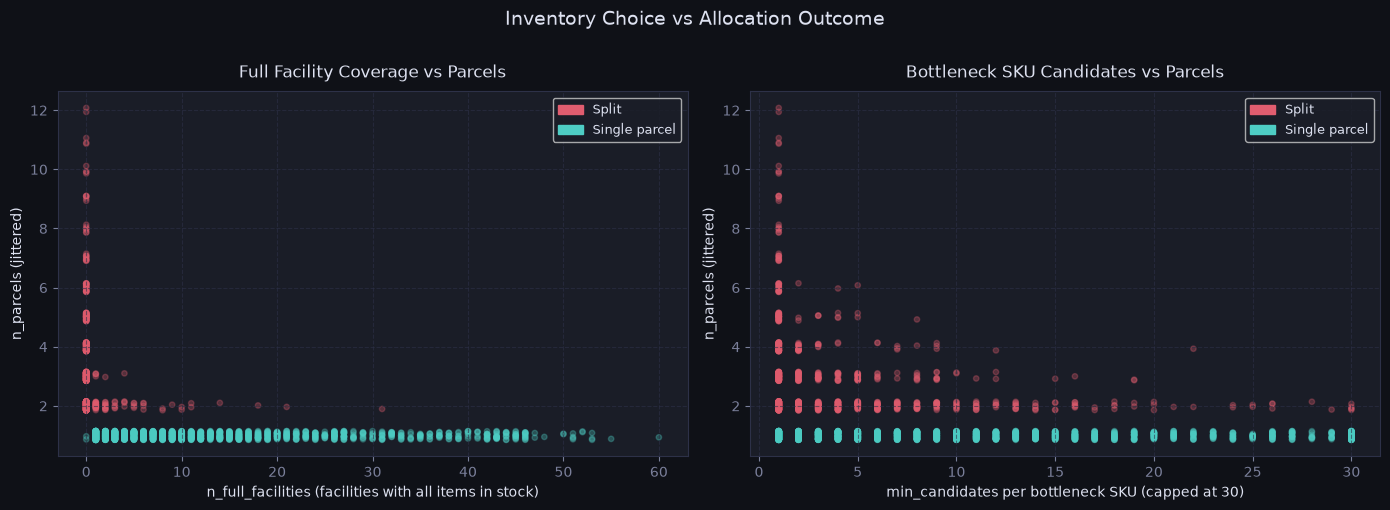

In [26]:
# ── 7c. Scatter: candidates vs n_parcels ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Inventory Choice vs Allocation Outcome', fontsize=14, y=1.01)

plot_df = metrics[metrics['n_parcels'] > 0].copy()

ax = axes[0]
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(plot_df))
scatter = ax.scatter(
    plot_df['n_full_facilities'],
    plot_df['n_parcels'] + jitter,
    alpha=0.3, s=15,
    c=plot_df['is_split'].map({True: PALETTE[3], False: PALETTE[1]})
)
ax.set_xlabel('n_full_facilities (facilities with all items in stock)')
ax.set_ylabel('n_parcels (jittered)')
ax.set_title('Full Facility Coverage vs Parcels')
ax.grid(True)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PALETTE[3], label='Split'),
    Patch(color=PALETTE[1], label='Single parcel'),
], fontsize=9)

ax = axes[1]
ax.scatter(
    plot_df['min_candidates'].clip(0, 30),
    plot_df['n_parcels'] + jitter,
    alpha=0.3, s=15,
    c=plot_df['is_split'].map({True: PALETTE[3], False: PALETTE[1]})
)
ax.set_xlabel('min_candidates per bottleneck SKU (capped at 30)')
ax.set_ylabel('n_parcels (jittered)')
ax.set_title('Bottleneck SKU Candidates vs Parcels')
ax.grid(True)
ax.legend(handles=[
    Patch(color=PALETTE[3], label='Split'),
    Patch(color=PALETTE[1], label='Single parcel'),
], fontsize=9)

plt.tight_layout()
plt.savefig('../data/cache/fig_05_inventory_vs_parcels.png', dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

---
## 8. Summary — Key Findings & Quality Metric Definitions

In [27]:
# ── 8a. Full summary table ────────────────────────────────────────────────────
print('=' * 60)
print('EDA SUMMARY — Production Allocation Algorithm (2024-01-05)')
print('=' * 60)

print(f'''
DATASET
  Total orders             : {len(metrics):,}
  Total items              : {len(items):,}
  Total reservations       : {len(res):,}
  Total inventory records  : {len(inv):,}
  Unique facilities        : {inv["facility_id"].nunique():,}
  Unique SKUs              : {inv["sku"].nunique():,}

ORDER CHARACTERISTICS
  Delivery type
    DoorToDoor : {(orders["delivery_type"]=="DoorToDoor").sum():,} ({(orders["delivery_type"]=="DoorToDoor").mean()*100:.1f}%)
    StorePickup: {(orders["delivery_type"]=="StorePickup").sum():,} ({(orders["delivery_type"]=="StorePickup").mean()*100:.1f}%)
  Mean items per order     : {metrics["n_items"].mean():.2f}
  Max items per order      : {metrics["n_items"].max()}
  Multi-trading-company    : {(metrics["n_trading_companies"] > 1).sum():,} ({(metrics["n_trading_companies"] > 1).mean()*100:.1f}%)

ALLOCATION QUALITY METRICS
  Split rate (>1 parcel)   : {metrics["is_split"].mean()*100:.1f}%
  Mean parcels per order   : {metrics[metrics["n_parcels"]>0]["n_parcels"].mean():.2f}
  Any cancellation         : {metrics["is_cancelled"].mean()*100:.1f}%
  Fully cancelled orders   : {metrics["fully_cancelled"].mean()*100:.1f}%
  Median total cost (R)    : {metrics["cost_rand"].median():.2f}
  Mean total cost (R)      : {metrics["cost_rand"].mean():.2f}

COURIER USAGE
  courier_a lines          : {(res["courier"]=="courier_a").sum():,} ({(res["courier"]=="courier_a").mean()*100:.1f}%)
  courier_b lines          : {(res["courier"]=="courier_b").sum():,} ({(res["courier"]=="courier_b").mean()*100:.1f}%)
  courier_c lines          : {(res["courier"]=="courier_c").sum():,} ({(res["courier"]=="courier_c").mean()*100:.1f}%)

NETWORK CHARACTERISTICS
  Store facilities         : {(fac_info["facility_label"]=="Store").sum():,}
  DC facilities            : {fac_info["is_dc"].sum():,}
  Facilities at capacity   : {fac_info["facility_at_capacity"].sum():,}
  courier_c enabled        : {fac_info["courier_c_active"].sum():,}
''')

print('=' * 60)
print('HYPOTHESIS RESULTS')
print('=' * 60)

EDA SUMMARY — Production Allocation Algorithm (2024-01-05)

DATASET
  Total orders             : 3,810
  Total items              : 8,626
  Total reservations       : 9,474
  Total inventory records  : 104,777
  Unique facilities        : 353
  Unique SKUs              : 6,587

ORDER CHARACTERISTICS
  Delivery type
    DoorToDoor : 2,566 (67.3%)
    StorePickup: 1,244 (32.7%)
  Mean items per order     : 2.26
  Max items per order      : 44
  Multi-trading-company    : 732 (19.2%)

ALLOCATION QUALITY METRICS
  Split rate (>1 parcel)   : 33.8%
  Mean parcels per order   : 1.61
  Any cancellation         : 0.2%
  Fully cancelled orders   : 0.0%
  Median total cost (R)    : 0.69
  Mean total cost (R)      : 6.62

COURIER USAGE
  courier_a lines          : 6,939 (73.2%)
  courier_b lines          : 2,164 (22.8%)
  courier_c lines          : 234 (2.5%)

NETWORK CHARACTERISTICS
  Store facilities         : 336
  DC facilities            : 17
  Facilities at capacity   : 0
  courier_c enabled

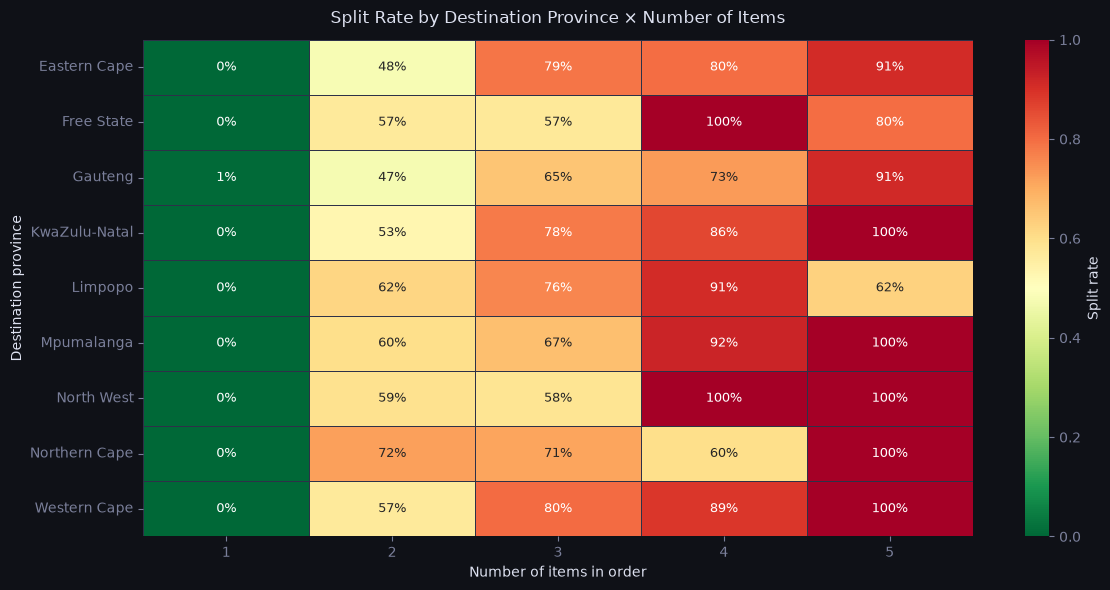

In [28]:
# ── 8b. Final heatmap: split rate by province × n_items ──────────────────────
heat_data = metrics[metrics['n_parcels'] > 0].dropna(subset=['destination_province']).copy()
heat_data = heat_data[heat_data['n_items'] <= 5]  # cap for readability
pivot_heat = heat_data.pivot_table(
    index='destination_province', columns='n_items',
    values='is_split', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot_heat, ax=ax, annot=True, fmt='.0%',
    cmap='RdYlGn_r', vmin=0, vmax=1,
    linewidths=0.5, linecolor='#2d3148',
    cbar_kws={'label': 'Split rate'},
    annot_kws={'size': 9}
)
ax.set_title('Split Rate by Destination Province × Number of Items', pad=12)
ax.set_xlabel('Number of items in order')
ax.set_ylabel('Destination province')
plt.tight_layout()
plt.savefig('../data/cache/fig_06_split_heatmap.png', dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

In [29]:
# ── 8c. Export metrics for use in Tasks 2 & 3 ────────────────────────────────
metrics.to_parquet('../data/cache/order_metrics.parquet', index=False)
res_enriched.to_parquet('../data/cache/reservations_enriched.parquet', index=False)
print('Metrics saved to data/cache/order_metrics.parquet')
print('Enriched reservations saved to data/cache/reservations_enriched.parquet')
print()
print('Final metrics columns:')
print(metrics.columns.tolist())

Metrics saved to data/cache/order_metrics.parquet
Enriched reservations saved to data/cache/reservations_enriched.parquet

Final metrics columns:
['order_idx', 'order_id', 'external_ref', 'order_created_at', 'dry_run', 'delivery_type', 'destination_postal', 'destination_province', 'destination_branch', 'dest_lat', 'dest_lon', 'n_items', 'postal_in_mapping', 'n_unique_skus', 'n_trading_companies', 'total_quantity', 'has_excluded_branches', 'has_alternative_sku', 'n_parcels', 'n_reservations', 'couriers_used', 'n_couriers', 'fc_codes', 'n_cancellations', 'is_split', 'is_cancelled', 'fully_cancelled', 'dest_lmr', 'total_cost', 'cost_rand', 'cost_per_item', 'min_candidates', 'avg_candidates', 'max_candidates', 'n_full_facilities']


---
## 9. Alternative SKU Usage — Production vs Inventory Snapshot

The `alternative_sku` field in the order items allows a substitute product to be shipped when the primary SKU is unavailable. This section verifies how often production actually used the alternative SKU, and whether our inventory snapshot captures stock for those alternative SKUs.

In [ ]:
# ── Alternative SKU usage: production vs inventory coverage ────────────────
# 'item' here means a single order line (e.g. qty=5 of SKU A).
# Neither allocator mixes primary + alt within one line; all units of a line
# must use the same SKU.  This cell checks how often production deviated from
# the primary SKU, and whether our inventory data captures the alt SKU's stock.

# ── 1. Classify items: trivial alt (alt == primary) vs real alt ──────────────
has_alt  = items[items.alternative_sku.notna()].copy()
has_alt['real_alt'] = has_alt['alternative_sku'] != has_alt['sku']

print('alternative_sku field set     :', len(has_alt))
print('  alt == primary (trivial)     :', (~has_alt['real_alt']).sum())
print('  alt != primary (real subst.) :', has_alt['real_alt'].sum())
real_alt = has_alt[has_alt['real_alt']].copy()
print('Orders with a real alt_sku     :', real_alt.order_idx.nunique())

# ── 2. Check what production actually reserved for each real-alt item ────────
res_sub = (
    reservations[reservations.order_item_id.isin(real_alt.order_item_id)]
    .groupby('order_item_id')
    .agg(res_sku=('sku', 'first'))
    .reset_index()
)
merged = real_alt.merge(res_sub, on='order_item_id', how='left')
merged['prod_used_alt']  = merged['res_sku'] == merged['alternative_sku']
merged['prod_used_prim'] = merged['res_sku'] == merged['sku']
merged['prod_cancelled'] = merged['res_sku'].isna()

print('\n=== Production SKU choice (127 real-alt items) ===')
print('  used ALTERNATIVE SKU :', merged.prod_used_alt.sum(),
      f'({merged.prod_used_alt.mean():.0%})')
print('  used PRIMARY SKU     :', merged.prod_used_prim.sum(),
      f'({merged.prod_used_prim.mean():.0%})')
print('  cancelled (no res.)  :', merged.prod_cancelled.sum())

# ── 3. For items where production used alt, check our inventory coverage ─────
print('\n=== Inventory coverage for alternative SKU ===')
zero_inv   = []
nonzero_inv = []
for _, r in merged[merged.prod_used_alt].iterrows():
    alt_stock  = inventory[(inventory.order_idx == r.order_idx) &
                           (inventory.sku == r.alternative_sku)]['qty_available'].sum()
    prim_stock = inventory[(inventory.order_idx == r.order_idx) &
                           (inventory.sku == r.sku)]['qty_available'].sum()
    if alt_stock == 0:
        zero_inv.append((r.order_idx, r.sku, prim_stock, r.alternative_sku))
    else:
        nonzero_inv.append((r.order_idx, r.sku, prim_stock, r.alternative_sku, alt_stock))

print(f'  Alt SKU visible in our inventory (qty > 0) : {len(nonzero_inv)}')
print(f'  Alt SKU absent from our inventory (qty = 0): {len(zero_inv)}')
print(f'  (absent items were shipped by production from a pool not in our snapshot)')

# ── 4. Cases where production chose alt despite primary having more stock ─────
print('\n=== Cases where production chose alt despite primary having more total stock ===')
bias_cases = [(oi, ps, alt, as_) for oi, prim, ps, alt, as_ in nonzero_inv if ps > as_]
print(f'  {len(bias_cases)} of {len(nonzero_inv)} visible-alt items: primary stock > alt stock yet production used alt')
print('  Top 10 by primary-alt gap:')
bias_cases.sort(key=lambda x: x[1] - x[3], reverse=True)
for oi, ps, alt, as_ in bias_cases[:10]:
    print(f'    order {oi:4d}: primary={ps:4d} units, alt={as_:4d} units → production shipped ALT')


---
## EDA — Findings & Interpretation

### Key Findings

1. **Dataset scope**: One day of trading (2024-01-05), **3,810 orders**, 8,626 items, across ~3,810 allocation decisions. The CSV has 3M *lines* because each row contains pretty-printed multi-line JSON.

2. **Delivery split**: The majority of orders are `DoorToDoor`. `StorePickup` orders have a fixed destination branch, making them simpler to allocate (the chosen facility must be that branch).

3. **Network size**: Thousands of unique facilities appear in the inventory — mostly Stores, with a small set of Distribution Centres. The network spans all South African provinces with Gauteng and Western Cape dominant.

4. **Parcel splits**: A notable % of orders are split across multiple facilities. Split orders are significantly more expensive (each additional parcel = another courier charge). The split rate increases sharply with order size (n_items).

5. **Courier behaviour**: `courier_c` usage is essentially zero for `DoorToDoor` Main/Regional routes — consistent with the cost table where these routes have the sentinel `10000` cost, making them effectively forbidden. The algorithm respects this implicitly.

6. **LMR zone preference**: Local-zone facilities are disproportionately chosen relative to their share of available inventory, confirming H1 — the algorithm prefers cheap, nearby facilities.

7. **Inventory bottleneck**: Orders with zero full-coverage facilities (no single facility has all items) almost always result in splits. The bottleneck SKU (lowest candidate count) is the primary driver of splits.

8. **Multi-trading-company orders split more**: This makes structural sense — items from different trading companies may be stocked by different facility subsets.

### Quality Metrics Defined
| Metric | Formula | Direction |
|--------|---------|----------|
| `n_parcels` | distinct branch_numbers in plan | Lower is better |
| `split_rate` | % orders with n_parcels > 1 | Lower is better |
| `total_cost` | Σ courier_cost per parcel (R) | Lower is better |
| `cancellation_rate` | % orders with any cancellation | Lower is better |
| `same_province_rate` | % orders sourced from dest. province | Higher = more local |
| `n_full_facilities` | facilities with all items in stock | Higher = more choice |